# Segmentación de municipios de Morelos con KMeans

**Materia:** Extracción de Conocimiento en Bases de Datos  
**Fuente principal:** INEGI — Censo de Población y Vivienda 2020 (ITER)  
**Validación externa:** CONAPO — Índices de Marginación 2020

**Pregunta guía:** ¿Qué municipios de Morelos presentan características similares en sus condiciones de vivienda, acceso a servicios y conectividad?

## Parte 1 — Imports y configuración

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

pd.set_option("display.max_columns", 50)
SEED = 42

BASE = Path.cwd().parent
RAW = BASE / "data" / "raw" / "iter_00_cpv2020" / "conjunto_de_datos" / "conjunto_de_datos_iter_00CSV20.csv"
OUT = BASE / "data" / "processed" / "dataset_limpio.csv"

## Parte 2 — Carga del dataset original

El archivo crudo nacional (`iter_00_cpv2020_csv.zip`, ~35 MB) no se incluye en el repositorio. Debe descargarse desde:
https://www.inegi.org.mx/contenidos/programas/ccpv/2020/datosabiertos/iter/iter_00_cpv2020_csv.zip

y extraerse en `data/raw/`. El CSV usa codificación UTF-8 con BOM (`utf-8-sig`).

In [2]:
df_raw = pd.read_csv(RAW, dtype=str, encoding="utf-8-sig")
print("Filas totales nacionales:", len(df_raw))
print("Columnas:", df_raw.shape[1])
df_raw.head(3)

Filas totales nacionales: 195662
Columnas: 286


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,POBFEM,POBMAS,P_0A2,P_0A2_F,P_0A2_M,P_3YMAS,P_3YMAS_F,P_3YMAS_M,P_5YMAS,P_5YMAS_F,P_5YMAS_M,P_12YMAS,P_12YMAS_F,P_12YMAS_M,P_15YMAS,...,VPH_C_SERV,VPH_NDEAED,VPH_DSADMA,VPH_NDACMM,VPH_SNBIEN,VPH_REFRI,VPH_LAVAD,VPH_HMICRO,VPH_AUTOM,VPH_MOTO,VPH_BICI,VPH_RADIO,VPH_TV,VPH_PC,VPH_TELEF,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC
0,00,Total nacional,000,Total nacional,0000,Total nacional,NaN,NaN,NaN,126014024,64540634,61473390,5764054,2848875,2915179,119976584,61554567,58422017,115693273,59433559,56259714,100528155,51962264,48565891,93985354,...,32671764,79584,32979844,16874580,581095,30811260,25610544,16651199,16340788,4227460,7469168,23772973,32031555,13204680,13184550,30775898,18307193,15211306,6616141,4047100,1788552,3170894,15108204,852871,*
1,00,Total nacional,000,Total nacional,9998,Localidades de una vivienda,NaN,NaN,NaN,250354,96869,153485,10493,5193,5300,239441,91463,147978,232086,87931,144155,207748,76111,131637,197411,...,35091,4842,43668,24373,5136,38199,26412,13608,30940,15001,13600,36738,40001,5797,3523,47005,8385,18981,1732,1113,12775,14143,51293,7154,*
2,00,Total nacional,000,Total nacional,9999,Localidades de dos viviendas,NaN,NaN,NaN,147125,61324,85801,6798,3407,3391,139757,57628,82129,135028,55256,79772,119223,47543,71680,111530,...,19807,2935,23841,16122,4115,21775,15880,7902,16699,8076,6330,20009,23198,3588,2177,25581,5027,11306,971,708,8247,10065,29741,5283,*


## Parte 3 — Revisión inicial de la estructura

Cada fila es una localidad. Los totales municipales son los registros con `LOC == "0000"`.

In [3]:
df_raw["NOM_LOC"].value_counts().head(8)

NOM_LOC
Total del Municipio             2469
Localidades de una vivienda     1990
Localidades de dos viviendas    1738
San Antonio                      647
Ninguno                          586
San José                         546
La Esperanza                     541
San Isidro                       536
Name: count, dtype: int64

## Parte 4 — Filtro: municipios de Morelos

- `LOC == "0000"`: registro municipal.
- `ENTIDAD == "17"`: Morelos.
- Se excluye la fila `MUN == "000"` (total de la entidad).

Se esperan exactamente **36 municipios**.

In [4]:
mun = df_raw[
    (df_raw["LOC"] == "0000")
    & (df_raw["ENTIDAD"] == "17")
    & (df_raw["MUN"] != "000")
].copy()
assert len(mun) == 36, f"Se esperaban 36 municipios, hay {len(mun)}"
mun[["MUN", "NOM_MUN", "POBTOT"]].head()

,MUN,NOM_MUN,POBTOT
104616,001,Amacuzac,17598
104650,002,Atlatlahucan,25232
104694,003,Axochiapan,39174
104755,004,Ayala,89834
104889,005,Coatlán del Río,10520


## Parte 5 — Limpieza de valores especiales y tipos

El ITER usa `*` para valores no disponibles por redondeo o por ley de confidencialidad. Se convierten las columnas seleccionadas a numérico (`errors="coerce"`) y se verifica que no queden valores nulos.

In [5]:
id_cols = ["MUN", "NOM_MUN"]
desc_cols = ["POBTOT", "TVIVHAB", "VIVPAR_HAB", "VIVPARH_CV"]
vph_cols = ["VPH_AGUADV", "VPH_DRENAJ", "VPH_C_ELEC", "VPH_INTER", "VPH_PC", "VPH_CEL", "VPH_AUTOM"]
direct_cols = ["GRAPROES", "PROM_OCUP"]

df = mun[id_cols + desc_cols + vph_cols + direct_cols].copy()

for c in desc_cols + vph_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
for c in direct_cols:
    df[c] = df[c].str.replace(",", ".", regex=False)
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Valores '*' en las columnas seleccionadas:", int((mun[desc_cols + vph_cols + direct_cols] == "*").sum().sum()))
print("Nulos tras conversión:", int(df.isna().sum().sum()))
df.describe().loc[["min", "max"]].round(2)

Valores '*' en las columnas seleccionadas: 0
Nulos tras conversión: 0


,POBTOT,TVIVHAB,VIVPAR_HAB,VIVPARH_CV,VPH_AGUADV,VPH_DRENAJ,VPH_C_ELEC,VPH_INTER,VPH_PC,VPH_CEL,VPH_AUTOM,GRAPROES,PROM_OCUP
min,7617.0,1965.0,1964.0,1959.0,1361.0,1025.0,1943.0,449.0,192.0,1674.0,505.0,6.92,3.19
max,378476.0,114742.0,106134.0,114442.0,113201.0,113963.0,114232.0,83635.0,62412.0,106004.0,60176.0,11.39,4.38


## Parte 6 — Selección de variables

Selección basada en el diccionario oficial (`referencias/fd_iter_cpv2020.pdf`):

| Variable | Significado | Rol |
|---|---|---|
| `VIVPARH_CV` | Viviendas particulares habitadas con características | Denominador |
| `VPH_AGUADV` | Agua entubada en la vivienda | Servicios |
| `VPH_DRENAJ` | Drenaje | Servicios |
| `VPH_C_ELEC` | Energía eléctrica | Servicios |
| `VPH_INTER` | Internet | Conectividad |
| `VPH_PC` | Computadora, laptop o tablet | Conectividad/equipamiento |
| `VPH_CEL` | Teléfono celular | Conectividad |
| `VPH_AUTOM` | Automóvil o camioneta | Equipamiento |
| `GRAPROES` | Grado promedio de escolaridad | Educación (directa) |
| `PROM_OCUP` | Promedio de ocupantes por vivienda | Densidad (directa) |

**Nota metodológica importante:** los conteos `VPH_*` se expresan respecto al universo de viviendas particulares habitadas **con características** (`VIVPARH_CV`), no respecto a `VIVPAR_HAB`. Al validar los datos se comprobó que dividir entre `VIVPAR_HAB` produce proporciones mayores a 1 en varios municipios, porque `VIVPARH_CV` es el universo real de esos indicadores según INEGI. `POBTOT` se conserva solo como variable descriptiva para evitar que el tamaño del municipio domine el clustering.

In [6]:
for c in vph_cols:
    df["p_" + c.replace("VPH_", "").lower()] = df[c] / df["VIVPARH_CV"]

prop_cols = [c for c in df.columns if c.startswith("p_")]
df[prop_cols].describe().loc[["min", "max", "mean"]].round(4)

,p_aguadv,p_drenaj,p_c_elec,p_inter,p_pc,p_cel,p_autom
min,0.6646,0.5232,0.9885,0.2292,0.0976,0.7485,0.1806
max,0.9929,0.9958,0.9982,0.7308,0.5454,0.9301,0.5258
mean,0.9321,0.9544,0.9933,0.4238,0.2604,0.8579,0.3763


## Parte 7 — Proporciones y verificación

Las proporciones deben quedar acotadas en [0, 1].

In [7]:
fuera_de_rango = int(((df[prop_cols] < 0) | (df[prop_cols] > 1)).sum().sum())
assert fuera_de_rango == 0, f"Proporciones fuera de rango: {fuera_de_rango}"
print("Todas las proporciones están en [0, 1]:", fuera_de_rango == 0)
df[["NOM_MUN"] + prop_cols].head()

Todas las proporciones están en [0, 1]: True


,NOM_MUN,p_aguadv,p_drenaj,p_c_elec,p_inter,p_pc,p_cel,p_autom
104616,Amacuzac,0.973462,0.954162,0.993164,0.385806,0.196823,0.815440,0.310615
104650,Atlatlahucan,0.838774,0.975053,0.988881,0.410834,0.292373,0.900927,0.430364
104694,Axochiapan,0.928917,0.963803,0.992942,0.333132,0.189655,0.855717,0.309639
104755,Ayala,0.940420,0.965205,0.991592,0.396597,0.262983,0.875996,0.333694
104889,Coatlán del Río,0.992308,0.951839,0.992642,0.279933,0.146823,0.748495,0.334783


## Parte 8 — Guardado del dataset procesado

Salida: `data/processed/dataset_limpio.csv` (36 filas, una por municipio). Este archivo sí se sube al repositorio.

In [8]:
df.to_csv(OUT, index=False, encoding="utf-8-sig")
verif = pd.read_csv(OUT)
print("Guardado:", OUT)
print("Filas:", len(verif), "| Columnas:", len(verif.columns))
verif.head()

Guardado: C:\Users\corey\OneDrive\Desktop\Proyecto-Articulo\data\processed\dataset_limpio.csv
Filas: 36 | Columnas: 22


,MUN,NOM_MUN,POBTOT,TVIVHAB,VIVPAR_HAB,VIVPARH_CV,VPH_AGUADV,VPH_DRENAJ,VPH_C_ELEC,VPH_INTER,VPH_PC,VPH_CEL,VPH_AUTOM,GRAPROES,PROM_OCUP,p_aguadv,p_drenaj,p_c_elec,p_inter,p_pc,p_cel,p_autom
0,1,Amacuzac,17598,4992,4794,4974,4842,4746,4940,1919,979,4056,1545,8.52,3.53,0.973462,0.954162,0.993164,0.385806,0.196823,0.815440,0.310615
1,2,Atlatlahucan,25232,7060,6574,7015,5884,6840,6937,2882,2051,6320,3019,9.34,3.57,0.838774,0.975053,0.988881,0.410834,0.292373,0.900927,0.430364
2,3,Axochiapan,39174,9978,9946,9918,9213,9559,9848,3304,1881,8487,3071,8.07,3.93,0.928917,0.963803,0.992942,0.333132,0.189655,0.855717,0.309639
3,4,Ayala,89834,25051,24852,24975,23487,24106,24765,9905,6568,21878,8334,8.69,3.57,0.940420,0.965205,0.991592,0.396597,0.262983,0.875996,0.333694
4,5,Coatlán del Río,10520,2996,2980,2990,2967,2846,2968,837,439,2238,1001,7.82,3.23,0.992308,0.951839,0.992642,0.279933,0.146823,0.748495,0.334783


## Parte 9 — Estadística descriptiva del dataset procesado

El análisis exploratorio se realiza a partir de `data/processed/dataset_limpio.csv`, de modo que esta fase depende únicamente del artefacto reproducible y no del archivo crudo nacional.

In [9]:
df = pd.read_csv(OUT)
print("Dimensiones:", df.shape)
print("Nulos totales:", int(df.isna().sum().sum()))
df.describe().round(3)

Dimensiones: (36, 22)
Nulos totales: 0


,MUN,POBTOT,TVIVHAB,VIVPAR_HAB,VIVPARH_CV,VPH_AGUADV,VPH_DRENAJ,VPH_C_ELEC,VPH_INTER,VPH_PC,VPH_CEL,VPH_AUTOM,GRAPROES,PROM_OCUP,p_aguadv,p_drenaj,p_c_elec,p_inter,p_pc,p_cel,p_autom
count,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000,36.000
mean,18.500,54764.444,15581.694,14893.778,15530.611,14893.833,15239.778,15455.806,8550.833,5690.278,13882.972,6523.250,9.055,3.607,0.932,0.954,0.993,0.424,0.260,0.858,0.376
std,10.536,73981.079,21999.617,20463.602,21939.924,21692.798,21886.929,21894.035,15556.103,11366.513,20342.164,11026.049,0.856,0.256,0.081,0.078,0.003,0.129,0.099,0.045,0.070
min,1.000,7617.000,1965.000,1964.000,1959.000,1361.000,1025.000,1943.000,449.000,192.000,1674.000,505.000,6.920,3.190,0.665,0.523,0.989,0.229,0.098,0.748,0.181
25%,9.750,15564.750,4090.750,4068.250,4075.250,3844.000,3899.000,4057.250,1402.750,776.000,3337.250,1348.000,8.620,3.430,0.924,0.954,0.991,0.324,0.195,0.823,0.349
50%,18.500,26518.500,6882.000,6493.000,6846.500,5724.000,6515.500,6770.500,2586.000,1717.000,6126.000,2747.500,8.975,3.550,0.971,0.974,0.993,0.400,0.258,0.862,0.374
75%,27.250,56482.750,15929.500,15465.500,15885.250,15157.000,15334.000,15768.750,9188.000,5525.750,14032.750,6754.750,9.395,3.822,0.978,0.983,0.995,0.486,0.306,0.891,0.405
max,36.000,378476.000,114742.000,106134.000,114442.000,113201.000,113963.000,114232.000,83635.000,62412.000,106004.000,60176.000,11.390,4.380,0.993,0.996,0.998,0.731,0.545,0.930,0.526


## Parte 10 — Distribuciones de las variables de segmentación

Se grafican las 7 proporciones de vivienda/conectividad más el grado promedio de escolaridad. La línea punteada marca la media estatal.

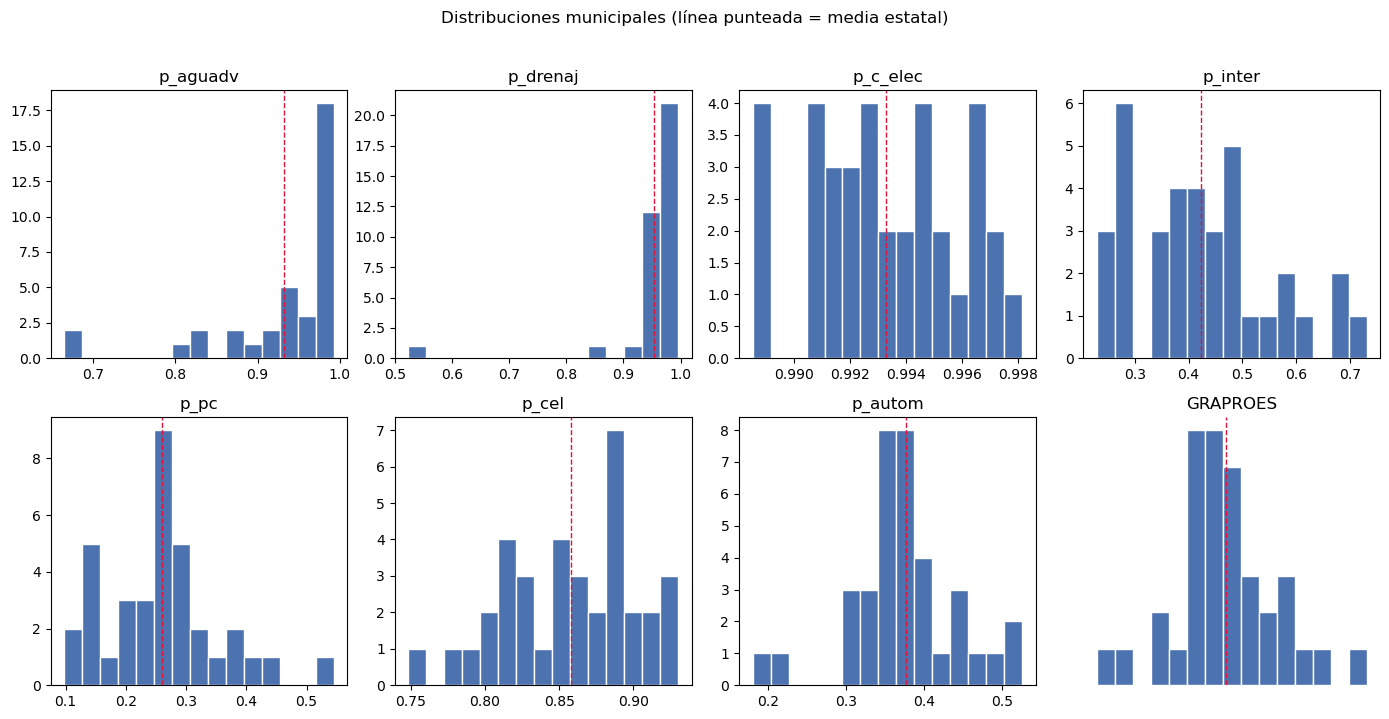

In [10]:
prop_cols = ["p_aguadv", "p_drenaj", "p_c_elec", "p_inter", "p_pc", "p_cel", "p_autom"]
IMG = BASE / "imagenes"

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, c in zip(axes.flat, prop_cols + ["GRAPROES"]):
    ax.hist(df[c], bins=15, color="#4C72B0", edgecolor="white")
    ax.axvline(df[c].mean(), color="crimson", linestyle="--", linewidth=1)
    ax.set_title(c)
axes.flat[-1].axis("off")
fig.suptitle("Distribuciones municipales (línea punteada = media estatal)", y=1.02)
fig.tight_layout()
fig.savefig(IMG / "grafica_1.png", dpi=150, bbox_inches="tight")
plt.show()

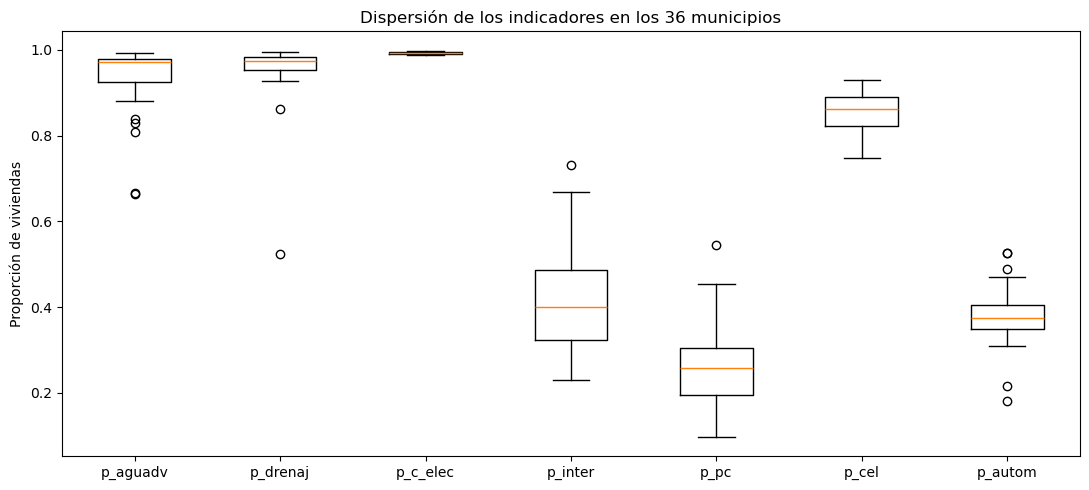

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot([df[c] for c in prop_cols], tick_labels=prop_cols)
ax.set_ylabel("Proporción de viviendas")
ax.set_title("Dispersión de los indicadores en los 36 municipios")
fig.tight_layout()
fig.savefig(IMG / "grafica_2.png", dpi=150, bbox_inches="tight")
plt.show()

## Parte 11 — Municipios extremos en acceso a internet

La conectividad (`p_inter`) es la variable con mayor rango observado. Se contrastan los 10 municipios con mayor y menor acceso.

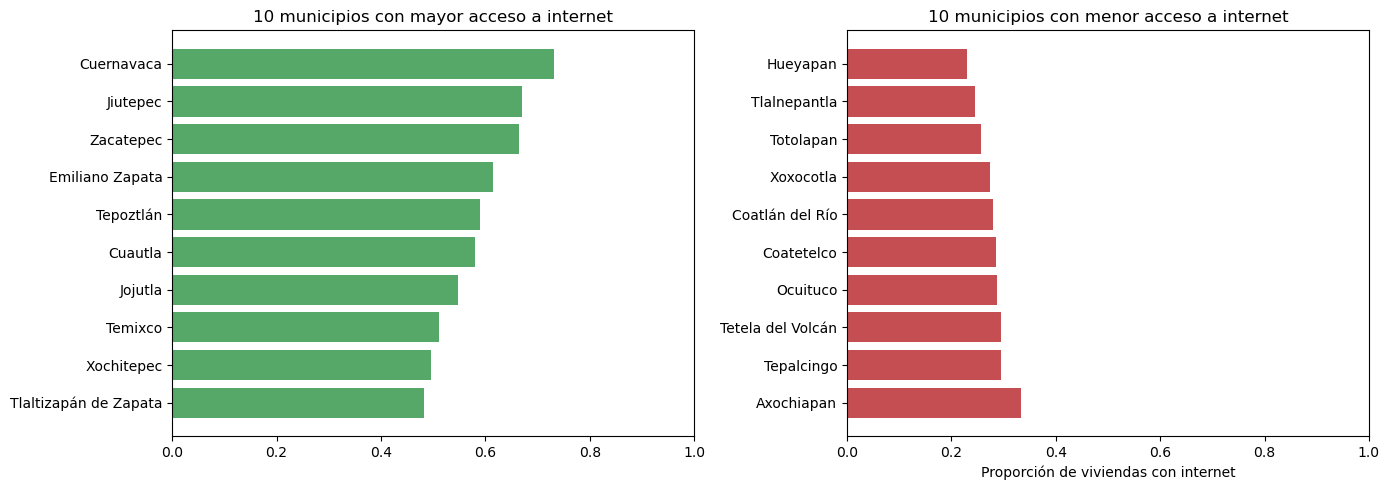

              NOM_MUN  p_inter
           Cuernavaca 0.730807
             Jiutepec 0.669482
            Zacatepec 0.664516
      Emiliano Zapata 0.615013
            Tepoztlán 0.589882
              Cuautla 0.580203
              Jojutla 0.546781
              Temixco 0.511854
           Xochitepec 0.495003
Tlaltizapán de Zapata 0.482444

          NOM_MUN  p_inter
       Axochiapan 0.333132
       Tepalcingo 0.294913
Tetela del Volcán 0.294399
         Ocuituco 0.287897
       Coatetelco 0.286021
  Coatlán del Río 0.279933
        Xoxocotla 0.273866
        Totolapan 0.256719
     Tlalnepantla 0.245117
         Hueyapan 0.229199


In [12]:
orden = df.sort_values("p_inter", ascending=False)
top = orden.head(10).iloc[::-1]
bottom = orden.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
axes[0].barh(top["NOM_MUN"], top["p_inter"], color="#55A868")
axes[0].set_title("10 municipios con mayor acceso a internet")
axes[1].barh(bottom["NOM_MUN"], bottom["p_inter"], color="#C44E52")
axes[1].set_title("10 municipios con menor acceso a internet")
axes[1].set_xlabel("Proporción de viviendas con internet")
for ax in axes:
    ax.set_xlim(0, 1)
fig.tight_layout()
fig.savefig(IMG / "grafica_3.png", dpi=150, bbox_inches="tight")
plt.show()

print(top[["NOM_MUN", "p_inter"]].iloc[::-1].to_string(index=False))
print()
print(bottom[["NOM_MUN", "p_inter"]].to_string(index=False))

## Parte 12 — Escolaridad y conectividad

Relación entre el grado promedio de escolaridad y el acceso a internet municipal.

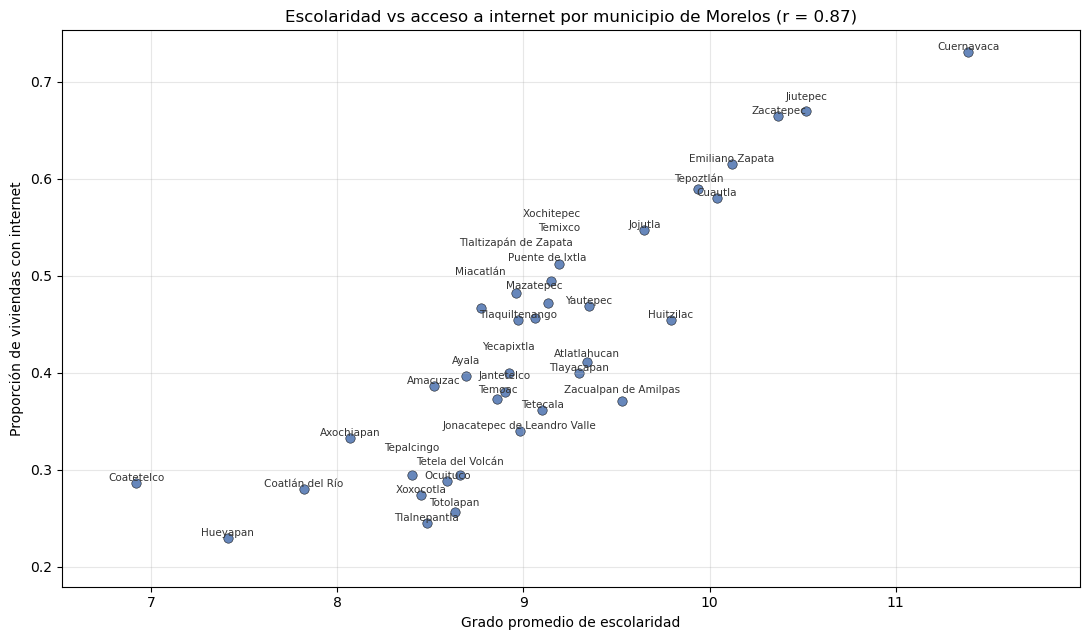

Correlación de Pearson: 0.872
Etiquetas colocadas sin traslapes: True


In [13]:
r = df["GRAPROES"].corr(df["p_inter"])

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.scatter(df["GRAPROES"], df["p_inter"], s=46, color="#4C72B0", alpha=0.85,
           edgecolor="black", linewidth=0.4)

etiquetas = [ax.text(x, y, nom, fontsize=7.5, ha="center", va="bottom", color="#333333")
             for nom, x, y in zip(df["NOM_MUN"], df["GRAPROES"], df["p_inter"])]

ax.set_xlim(df["GRAPROES"].min() - 0.4, df["GRAPROES"].max() + 0.6)
ax.set_ylim(df["p_inter"].min() - 0.05, df["p_inter"].max() + 0.07)
ax.set_xlabel("Grado promedio de escolaridad")
ax.set_ylabel("Proporción de viviendas con internet")
ax.set_title(f"Escolaridad vs acceso a internet por municipio de Morelos (r = {r:.2f})")
ax.grid(alpha=0.3)

fig.canvas.draw()
rend = fig.canvas.get_renderer()
inv = ax.transData.inverted()


def _paso_datos(delta_px):
    _, y0 = inv.transform((0, 0))
    _, y1 = inv.transform((0, delta_px))
    return y1 - y0


y_min_actual, _ = ax.get_ylim()
for _ in range(300):
    cajas = [t.get_window_extent(renderer=rend) for t in etiquetas]
    choques = []
    for i in range(len(etiquetas)):
        for j in range(i + 1, len(etiquetas)):
            dxs = min(cajas[i].x1, cajas[j].x1) - max(cajas[i].x0, cajas[j].x0)
            dys = min(cajas[i].y1, cajas[j].y1) - max(cajas[i].y0, cajas[j].y0)
            if dxs > 0 and dys > 0:
                choques.append((i, j, dys))
    if not choques:
        break
    for i, j, dys in choques:
        ci = (cajas[i].y0 + cajas[i].y1) / 2
        cj = (cajas[j].y0 + cajas[j].y1) / 2
        sube = j if cj >= ci else i
        px, py = etiquetas[sube].get_position()
        etiquetas[sube].set_position((px, py + _paso_datos(dys + 2.0)))

cajas_finales = [t.get_window_extent(renderer=rend) for t in etiquetas]
tope_datos = max(inv.transform((0, b.y1))[1] for b in cajas_finales)
ax.set_ylim(y_min_actual, tope_datos + _paso_datos(8))

fig.tight_layout()
fig.savefig(IMG / "grafica_4.png", dpi=150, bbox_inches="tight")
plt.show()
print("Correlación de Pearson:", round(r, 3))
print("Etiquetas colocadas sin traslapes:", len(choques) == 0)


## Parte 13 — Correlaciones entre variables de segmentación

Matriz de correlaciones de las 9 variables candidatas al KMeans. Sirve para detectar redundancias antes del modelado.

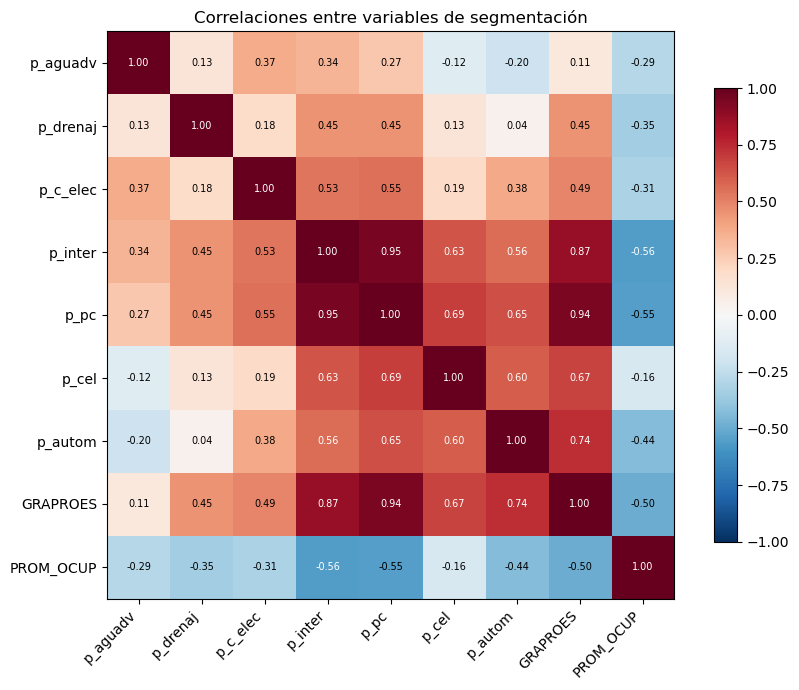

Pares más correlacionados:
p_pc      p_inter     0.950662
p_inter   p_pc        0.950662
GRAPROES  p_pc        0.940325
p_pc      GRAPROES    0.940325

PROM_OCUP  p_pc        -0.547358
p_pc       PROM_OCUP   -0.547358
p_inter    PROM_OCUP   -0.556909
PROM_OCUP  p_inter     -0.556909


In [14]:
corr_vars = prop_cols + ["GRAPROES", "PROM_OCUP"]
corr = df[corr_vars].corr()
n = len(corr_vars)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n), corr_vars, rotation=45, ha="right")
ax.set_yticks(range(n), corr_vars)
for i in range(n):
    for j in range(n):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(v) > 0.55 else "black")
fig.colorbar(im, shrink=0.8)
ax.set_title("Correlaciones entre variables de segmentación")
fig.tight_layout()
fig.savefig(IMG / "grafica_5.png", dpi=150, bbox_inches="tight")
plt.show()

sin_diag = corr.where(~np.eye(n, dtype=bool)).stack().sort_values(ascending=False)
print("Pares más correlacionados:")
print(sin_diag.head(4).to_string())
print()
print(sin_diag.tail(4).to_string())

## Parte 14 — Variables finales y estandarización

**Decisión del equipo:** se elimina `p_pc` de las variables de clustering porque su correlación con `p_inter` es r = 0.97 (miden prácticamente la misma dimensión y la sobre-representarían en el cálculo de distancias). Se conservan **8 variables**. `GRAPROES` y `p_inter` mantienen correlación alta (r = 0.94) pero miden conceptos distintos (educación vs conectividad), por lo que se conservan ambas.

Antes de KMeans todas las variables se estandarizan con `StandardScaler`, porque están en escalas distintas (proporciones 0–1, escolaridad en años, ocupantes por vivienda).

In [15]:
clust_vars = ["p_aguadv", "p_drenaj", "p_c_elec", "p_inter", "p_cel", "p_autom", "GRAPROES", "PROM_OCUP"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[clust_vars])
pd.DataFrame(X_scaled, columns=clust_vars).describe().loc[["mean", "std"]].round(3)

,p_aguadv,p_drenaj,p_c_elec,p_inter,p_cel,p_autom,GRAPROES,PROM_OCUP
mean,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000
std,1.014,1.014,1.014,1.014,1.014,1.014,1.014,1.014


## Parte 15 — Elección del número de clusters (k)

Se evalúan dos criterios para k entre 2 y 10:

- **Método del codo** (inercia): busca el punto donde agregar clusters deja de reducir mucho la dispersión interna.
- **Coeficiente de silueta**: mide qué tan bien cada municipio queda dentro de su cluster frente a los vecinos más cercanos (entre −1 y 1; más alto es mejor).

 k  inercia  silueta
 2 206.5042   0.2466
 3 165.0546   0.2732
 4 130.6667   0.2648
 5 101.8692   0.3031
 6  84.1706   0.2450
 7  66.6764   0.2633
 8  53.4919   0.2714
 9  44.8557   0.2777
10  39.7533   0.2513


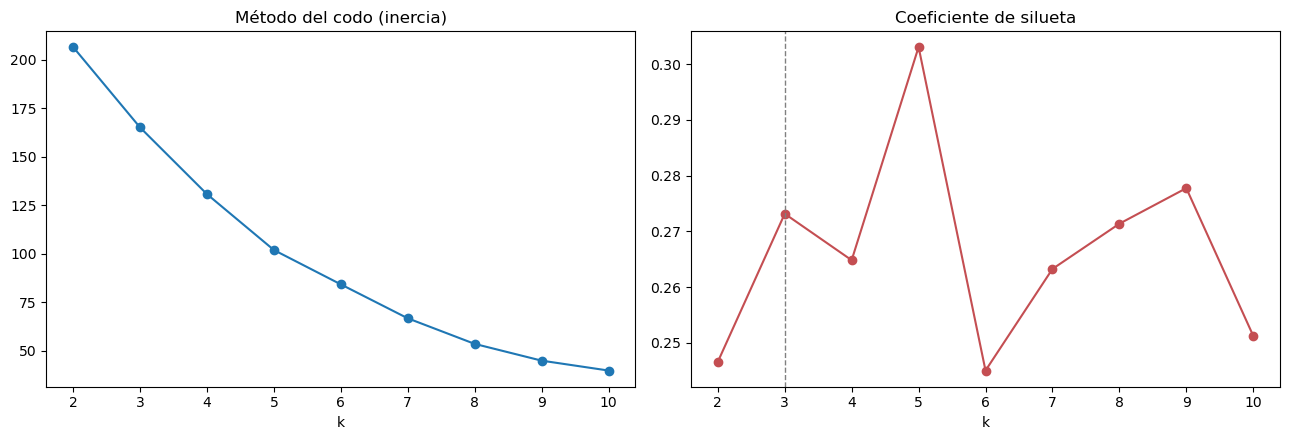

In [16]:
resultados_k = []
for k in range(2, 11):
    km_tmp = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_scaled)
    resultados_k.append({"k": k, "inercia": km_tmp.inertia_,
                         "silueta": silhouette_score(X_scaled, km_tmp.labels_)})
tabla_k = pd.DataFrame(resultados_k)
print(tabla_k.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(tabla_k["k"], tabla_k["inercia"], marker="o")
axes[0].set_title("Método del codo (inercia)")
axes[0].set_xlabel("k")
axes[1].plot(tabla_k["k"], tabla_k["silueta"], marker="o", color="#C44E52")
axes[1].axvline(3, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Coeficiente de silueta")
axes[1].set_xlabel("k")
fig.tight_layout()
fig.savefig(IMG / "grafica_6.png", dpi=150, bbox_inches="tight")
plt.show()

**Justificación de la elección:** con los 36 municipios de Morelos, la silueta maximiza en k = 5 (0.30), pero esa solución produce grupos de solo 1 y 2 municipios (uno quedaría integrado por un único municipio con drenaje extremadamente bajo), lo que no es interpretable ni útil. Con k = 2 la silueta cae a 0.247 y mezcla realidades muy distintas en dos bloques grandes. El equipo eligió **k = 3** (silueta ≈ 0.273) porque el codo se flexiona entre k = 3 y k = 4 y los tres grupos resultantes tienen tamaños razonables (9, 7 y 20) y lectura clara para contrastarse después con los grados de marginación de CONAPO. La preferencia de la métrica por k = 5 se documenta como parte de la decisión.

## Parte 16 — Entrenamiento del modelo final

KMeans con `random_state` fijo (`SEED = 42`) y `n_init = 10` para garantizar reproducibilidad. Las etiquetas numéricas de los clusters son arbitrarias; se renombran según el nivel promedio de conectividad (`p_inter`) en niveles **bajo / intermedio / alto**, sin que ello implique categorías oficiales.

In [17]:
k_final = 3
km = KMeans(n_clusters=k_final, n_init=10, random_state=SEED)
df["cluster"] = km.fit_predict(X_scaled)

orden = df.groupby("cluster")["p_inter"].mean().sort_values().index
nombres = dict(zip(orden, ["bajo", "intermedio", "alto"]))
df["perfil"] = df["cluster"].map(nombres)

print("Silueta del modelo final:", round(silhouette_score(X_scaled, km.labels_), 4))
print(df["perfil"].value_counts().reindex(["bajo", "intermedio", "alto"]))

Silueta del modelo final: 0.2732
perfil
bajo          20
intermedio     7
alto           9
Name: count, dtype: int64


## Parte 17 — Perfiles promedio de los clusters

Promedios en unidades originales por grupo, y mapa de calor de los perfiles estandarizados (desviaciones respecto a la media estatal) para visualizar qué caracteriza a cada cluster.

            municipios  p_aguadv  p_drenaj  p_c_elec  p_inter  p_cel  p_autom  GRAPROES  PROM_OCUP
perfil                                                                                            
bajo                20     0.960     0.942     0.993    0.362  0.828    0.337     8.590      3.656
intermedio           7     0.798     0.941     0.991    0.391  0.882    0.430     9.197      3.653
alto                 9     0.975     0.992     0.996    0.587  0.906    0.423     9.976      3.460


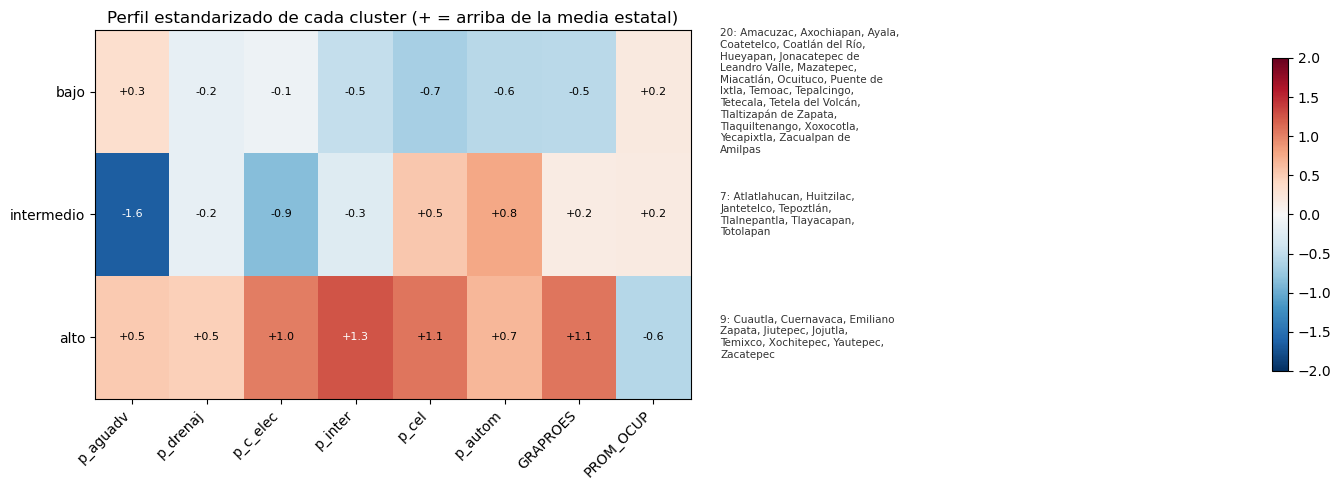

      alto: Cuernavaca, Jiutepec, Cuautla, Temixco
intermedio: Tepoztlán, Atlatlahucan, Huitzilac, Tlayacapan
      bajo: Ayala, Yecapixtla, Tlaltizapán de Zapata, Puente de Ixtla


In [18]:
import textwrap

perf = df.groupby("perfil")[clust_vars].mean().reindex(["bajo", "intermedio", "alto"]).round(3)
perf_n = df.groupby("perfil").size().reindex(["bajo", "intermedio", "alto"])
perf.insert(0, "municipios", perf_n)
print(perf.to_string())

z = (perf[clust_vars] - df[clust_vars].mean()) / df[clust_vars].std()
fig, ax = plt.subplots(figsize=(15, 5))
im = ax.imshow(z, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(clust_vars)), clust_vars, rotation=45, ha="right")
ax.set_yticks(range(len(z)), z.index)
for i in range(len(z)):
    for j in range(len(clust_vars)):
        ax.text(j, i, f"{z.iloc[i, j]:+.1f}", ha="center", va="center", fontsize=8,
                color="white" if abs(z.iloc[i, j]) > 1.2 else "black")
fig.colorbar(im, shrink=0.85, pad=0.42)
ax.set_title("Perfil estandarizado de cada cluster (+ = arriba de la media estatal)")
trans = ax.get_yaxis_transform()
for i, p in enumerate(["bajo", "intermedio", "alto"]):
    miembros = textwrap.fill(", ".join(sorted(df.loc[df["perfil"] == p, "NOM_MUN"])), 30)
    ax.text(1.05, i, f"{int(perf.loc[p, 'municipios'])}: {miembros}", transform=trans,
            va="center", fontsize=7.5, color="#333333")
fig.tight_layout()
fig.savefig(IMG / "grafica_7.png", dpi=150, bbox_inches="tight")
plt.show()

for p in ["alto", "intermedio", "bajo"]:
    ej = df[df["perfil"] == p].nlargest(4, "POBTOT")["NOM_MUN"].tolist()
    print(f'{p:>10}:', ', '.join(ej))


## Parte 18 — Exportación de resultados

- `outputs/resultados_modelo.csv`: municipio + cluster asignado + variables usadas.
- `outputs/resumen_resultados.csv`: perfil promedio por cluster.

In [19]:
res = df[["MUN", "NOM_MUN", "POBTOT", "cluster", "perfil"] + clust_vars]
res.to_csv(BASE / "outputs" / "resultados_modelo.csv", index=False, encoding="utf-8-sig")

resumen = df.groupby("perfil")[clust_vars].mean().round(4).reindex(["bajo", "intermedio", "alto"])
resumen.insert(0, "municipios", df.groupby("perfil").size().reindex(["bajo", "intermedio", "alto"]))
resumen.to_csv(BASE / "outputs" / "resumen_resultados.csv", encoding="utf-8-sig")

print("Archivos generados en outputs/:")
for f in sorted((BASE / "outputs").glob("*.csv")):
    print(" -", f.name)

Archivos generados en outputs/:
 - cruce_conapo_perfiles.csv
 - resultados_modelo.csv
 - resumen_resultados.csv


## Parte 19 — Árbol de decisión como herramienta explicativa

Se entrena un `DecisionTreeClassifier` usando el **perfil asignado por KMeans como variable objetivo**, con las mismas 8 variables del clustering. El fin no es predecir sino **interpretar**: obtener reglas legibles que muestren qué variables y umbrales usó KMeans para separar a los municipios.

Por eso **no se divide en entrenamiento/prueba**: el árbol debe describir todos los municipios, no generalizar a datos nuevos.

**Advertencia metodológica:** la etiqueta objetivo fue creada por un algoritmo, **no es una categoría oficial ni una verdad externa**; el árbol solo traduce las fronteras internas de KMeans. El contraste con una fuente independiente se realiza en la Fase 6 con CONAPO.

In [20]:
X_tree = df[clust_vars]
y_tree = df["perfil"]

arbol = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=SEED)
arbol.fit(X_tree, y_tree)

print("Precisión del árbol reproduciendo los clusters:", round(arbol.score(X_tree, y_tree), 3))
print("Profundidad:", arbol.get_depth(), "| Hojas:", arbol.get_n_leaves())

coincide = pd.crosstab(y_tree, pd.Series(arbol.predict(X_tree), index=df.index, name="predicho"))
print(coincide)

Precisión del árbol reproduciendo los clusters: 0.972
Profundidad: 2 | Hojas: 3
predicho    alto  bajo  intermedio
perfil                            
alto           9     0           0
bajo           0    19           1
intermedio     0     0           7


La coincidencia alta se esperaba: el árbol aprende de las mismas variables que KMeans, así que sirve para **hacer legible** la frontera, no para validarla.

## Parte 20 — Reglas legibles e importancia de las variables

Las reglas en texto (`export_text`) y el diagrama del árbol muestran la lógica de separación; la importancia global indica cuánto contribuye cada variable a discriminar entre perfiles.

|--- p_drenaj <= 0.98
|   |--- p_aguadv <= 0.91
|   |   |--- class: intermedio
|   |--- p_aguadv >  0.91
|   |   |--- class: bajo
|--- p_drenaj >  0.98
|   |--- class: alto



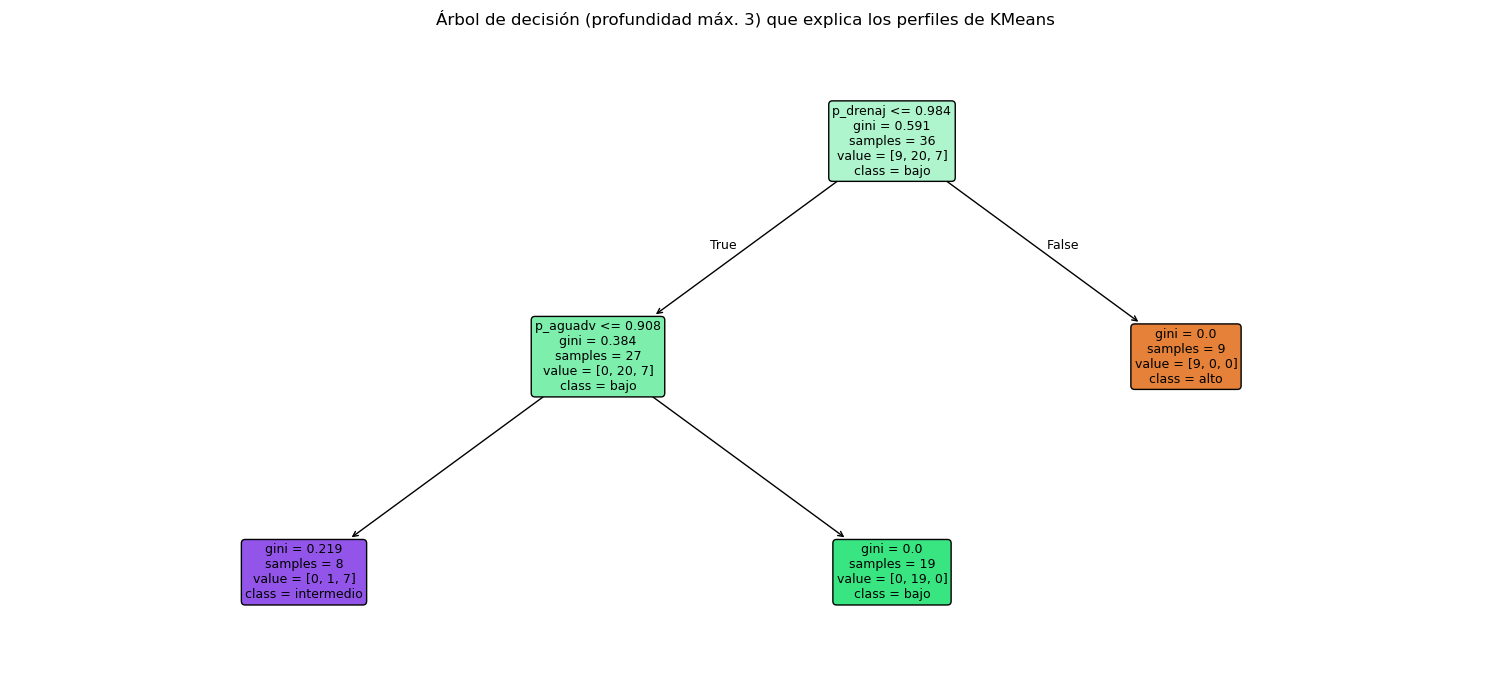

In [21]:
print(export_text(arbol, feature_names=clust_vars))

fig, ax = plt.subplots(figsize=(15, 7))
plot_tree(arbol, feature_names=clust_vars, class_names=list(arbol.classes_),
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Árbol de decisión (profundidad máx. 3) que explica los perfiles de KMeans")
fig.tight_layout()
fig.savefig(IMG / "grafica_8.png", dpi=150, bbox_inches="tight")
plt.show()

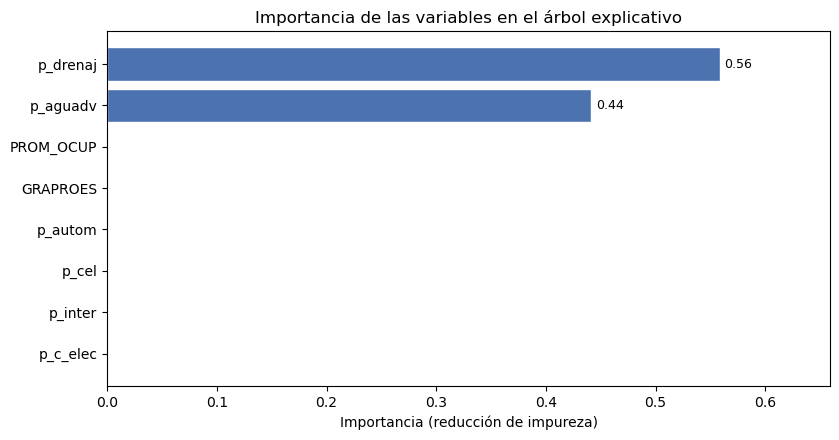

p_drenaj     0.559
p_aguadv     0.441
p_c_elec     0.000
p_inter      0.000
p_cel        0.000
p_autom      0.000
GRAPROES     0.000
PROM_OCUP    0.000


In [22]:
imp = pd.Series(arbol.feature_importances_, index=clust_vars).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.barh(imp.index, imp.values, color="#4C72B0", edgecolor="white")
for i, v in enumerate(imp.values):
    if v > 0:
        ax.text(v + 0.004, i, f"{v:.2f}", va="center", fontsize=9)
ax.set_xlim(0, max(imp.max() * 1.18, 0.05))
ax.set_title("Importancia de las variables en el árbol explicativo")
ax.set_xlabel("Importancia (reducción de impureza)")
fig.tight_layout()
fig.savefig(IMG / "grafica_9.png", dpi=150, bbox_inches="tight")
plt.show()

print(imp.sort_values(ascending=False).round(3).to_string())

## Parte 21 — Fuente externa: marginación municipal de CONAPO 2020

Se carga la base municipal del **Índice de Marginación de CONAPO 2020** (`IMM_2020.xls`, descargada de la página oficial y guardada en `data/raw/`). Contiene el índice (`IM_2020`) y el **grado** de marginación (`GM_2020`, cinco categorías) calculados por CONAPO con su propia metodología e indicadores distintos a los nuestros.

El cruce se hace por clave geoestadística: la clave municipal de CONAPO equivale a `17000 + MUN` (entidad 15 + municipio).

**Encuadre metodológico:** esta fuente NO valida matemáticamente los clusters ni implica que KMeans mida marginación; solo permite **observar si existen patrones compatibles o diferencias** entre dos miradas independientes sobre condiciones socioeconómicas municipales.

In [23]:
CONAPO_FILE = BASE / "data" / "raw" / "IMM_2020.xls"
conapo = pd.read_excel(CONAPO_FILE, sheet_name="IMM_2020")

df["CVE_MUN"] = 17000 + df["MUN"]
df = df.merge(conapo[["CVE_MUN", "POB_TOT", "IM_2020", "GM_2020"]],
              on="CVE_MUN", how="left", validate="one_to_one")

print("Filas tras el cruce:", len(df), "| Grados sin asignar:", df["GM_2020"].isna().sum())

dif_pob = ((df["POBTOT"] - df["POB_TOT"]).abs() / df["POBTOT"])
print("Control de calidad del cruce — máx. diferencia relativa de población:", round(dif_pob.max(), 5))
print("Distribución estatal del grado de marginación:")
print(df["GM_2020"].value_counts().reindex(["Muy bajo", "Bajo", "Medio", "Alto", "Muy alto"]).fillna(0).astype(int))

Filas tras el cruce: 36 | Grados sin asignar: 0
Control de calidad del cruce — máx. diferencia relativa de población: 0.0
Distribución estatal del grado de marginación:
GM_2020
Muy bajo    12
Bajo        19
Medio        5
Alto         0
Muy alto     0
Name: count, dtype: int64


La población coincide al 100% entre ambas fuentes (ambas provienen del Censo 2020), lo que confirma que el cruce por clave es correcto.

## Parte 22 — ¿Los perfiles de KMeans se parecen a los grados de marginación?

Se cruza el perfil asignado por KMeans con el grado oficial de marginación. Si los patrones fueran compatibles, los municipios del perfil *bajo* deberían concentrar los grados de marginación más altos, y viceversa, aunque **no se espera correspondencia exacta**: las variables y la metodología son distintas.

Conteos (perfil × grado de marginación):
GM_2020     Muy bajo  Bajo  Medio  Alto  Muy alto
perfil                                           
bajo               3    14      3     0         0
intermedio         0     5      2     0         0
alto               9     0      0     0         0

Porcentaje dentro de cada perfil (%):
GM_2020     Muy bajo  Bajo  Medio  Alto  Muy alto
perfil                                           
bajo            15.0  70.0   15.0   0.0       0.0
intermedio       0.0  71.4   28.6   0.0       0.0
alto           100.0   0.0    0.0   0.0       0.0

Mediana del índice de marginación (IM_2020) por perfil:
perfil
bajo          55.74
intermedio    55.39
alto          57.96
Name: IM_2020, dtype: float64


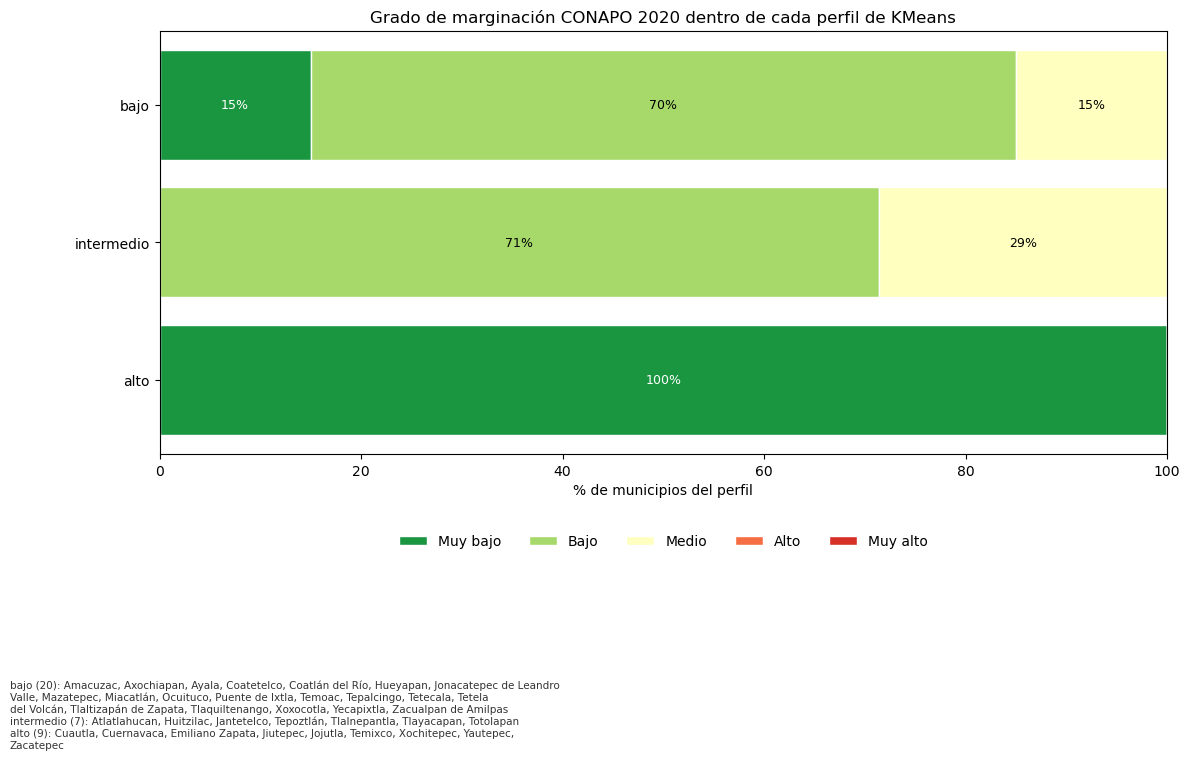

In [24]:
import textwrap

orden_gm = ["Muy bajo", "Bajo", "Medio", "Alto", "Muy alto"]
orden_perf = ["bajo", "intermedio", "alto"]

tabla_gm = pd.crosstab(df["perfil"], df["GM_2020"]).reindex(index=orden_perf,
                                                           columns=orden_gm).fillna(0).astype(int)
tabla_pct = tabla_gm.div(tabla_gm.sum(axis=1), axis=0)
print("Conteos (perfil × grado de marginación):")
print(tabla_gm.to_string())
print("\nPorcentaje dentro de cada perfil (%):")
print((tabla_pct * 100).round(1).to_string())

print("\nMediana del índice de marginación (IM_2020) por perfil:")
print(df.groupby("perfil")["IM_2020"].median().reindex(orden_perf).round(2))

colores = {"Muy bajo": "#1A9641", "Bajo": "#A6D96A", "Medio": "#FFFFBF",
           "Alto": "#F46D43", "Muy alto": "#D73027"}
fig, ax = plt.subplots(figsize=(13, 5.5))
izq = pd.Series(0, index=tabla_pct.index, dtype=float)
for g in orden_gm:
    vals = tabla_pct[g] * 100
    ax.barh(vals.index, vals, left=izq, color=colores[g], label=g, edgecolor="white")
    for i, (v, l) in enumerate(zip(vals, izq)):
        if v >= 5:
            ax.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center", fontsize=9,
                    color="black" if g in ("Medio", "Bajo") else "white")
    izq += vals
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("% de municipios del perfil")
ax.set_title("Grado de marginación CONAPO 2020 dentro de cada perfil de KMeans")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=5, frameon=False)

bloque = []
for p in orden_perf:
    miembros = textwrap.fill(", ".join(sorted(df.loc[df["perfil"] == p, "NOM_MUN"])), 95)
    bloque.append(f"{p} ({int(tabla_gm.loc[p].sum())}): {miembros}")
fig.text(0.01, -0.30, "\n".join(bloque), fontsize=7.5, va="top", color="#333333")

fig.savefig(IMG / "grafica_10.png", dpi=150, bbox_inches="tight")
plt.show()


## Parte 23 — Coincidencias, diferencias y exportación del cruce

Los casos **discordantes** son especialmente útiles para el artículo: municipios donde la lectura de KMeans (vivienda, servicios, conectividad) y la de CONAPO (educación, ingresos, ocupación, vivienda) no coinciden.

In [25]:
dis_alto = df[(df["perfil"] == "alto") & (df["GM_2020"].isin(["Alto", "Muy alto"]))]
dis_bajo = df[(df["perfil"] == "bajo") & (df["GM_2020"].isin(["Bajo", "Muy bajo"]))]

cols_dis = ["NOM_MUN", "perfil", "GM_2020", "p_inter", "p_drenaj", "GRAPROES"]
print("Perfil ALTO de KMeans pero marginación Alta/Muy alta según CONAPO:")
print(dis_alto[cols_dis].to_string(index=False) if len(dis_alto) else "(ninguno)")
print("\nPerfil BAJO de KMeans pero marginación Baja/Muy baja según CONAPO:")
print(dis_bajo[cols_dis].to_string(index=False) if len(dis_bajo) else "(ninguno)")

salida_cruce = df[["MUN", "NOM_MUN", "perfil", "IM_2020", "GM_2020"]]
salida_cruce.to_csv(BASE / "outputs" / "cruce_conapo_perfiles.csv", index=False, encoding="utf-8-sig")
print("\nExportado: outputs/cruce_conapo_perfiles.csv")

Perfil ALTO de KMeans pero marginación Alta/Muy alta según CONAPO:
(ninguno)

Perfil BAJO de KMeans pero marginación Baja/Muy baja según CONAPO:
                     NOM_MUN perfil  GM_2020  p_inter  p_drenaj  GRAPROES
                    Amacuzac   bajo     Bajo 0.385806  0.954162      8.52
                       Ayala   bajo     Bajo 0.396597  0.965205      8.69
             Coatlán del Río   bajo     Bajo 0.279933  0.951839      7.82
Jonacatepec de Leandro Valle   bajo     Bajo 0.339581  0.974342      8.98
                   Mazatepec   bajo     Bajo 0.455964  0.982316      9.06
                   Miacatlán   bajo Muy bajo 0.466215  0.980101      8.77
                    Ocuituco   bajo     Bajo 0.287897  0.944713      8.59
             Puente de Ixtla   bajo Muy bajo 0.472348  0.977452      9.13
                  Tepalcingo   bajo     Bajo 0.294913  0.934836      8.40
                    Tetecala   bajo     Bajo 0.361845  0.978197      9.10
           Tetela del Volcán   bajo     B